In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("air_quality_dataset.csv")

In [3]:
df.head()

,Date,City,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
0,16-10-2024,Los Angeles,128.0,28.78,68.84,58.29,57.56,2.781,17.10,3.4,82.2
1,26-01-2023,Jacksonville,111.0,28.73,61.93,59.00,35.73,NaN,16.33,17.0,36.0
2,09-10-2023,Houston,91.0,20.04,47.10,NaN,43.91,NaN,15.27,1.0,68.6
3,17-08-2023,Chicago,108.0,23.39,47.90,62.85,48.89,NaN,18.49,9.4,85.7
4,15-04-2023,Austin,106.0,26.51,56.08,62.38,NaN,NaN,15.93,17.3,48.7


In [4]:
df.columns

Index(['Date', 'City', 'AQI', 'PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2',
       'Temperature', 'Humidity'],
      dtype='object')

In [5]:
(df == -200).sum()

Date           0
City           0
AQI            0
PM2.5          0
PM10           0
Ozone          0
NO2            0
CO             0
SO2            0
Temperature    0
Humidity       0
dtype: int64

In [6]:
df.replace(-200,np.nan,inplace=True)

In [7]:
df.isnull().sum()

Date              0
City              0
AQI             111
PM2.5            97
PM10             60
Ozone          2921
NO2              93
CO             1040
SO2             129
Temperature     148
Humidity        104
dtype: int64

In [8]:
df=df.loc[:,~df.columns.str.contains('Unnamed')]

In [9]:
df.isnull().sum()

Date              0
City              0
AQI             111
PM2.5            97
PM10             60
Ozone          2921
NO2              93
CO             1040
SO2             129
Temperature     148
Humidity        104
dtype: int64

In [10]:
df['AQI'].isnull().sum()

np.int64(111)

In [11]:
(df.isnull().sum()/len(df))*100

Date            0.000000
City            0.000000
AQI             1.988178
PM2.5           1.737417
PM10            1.074691
Ozone          52.319541
NO2             1.665771
CO             18.627978
SO2             2.310586
Temperature     2.650905
Humidity        1.862798
dtype: float64

In [12]:
threshold=40
df=df.loc[:,(df.isnull().sum()/len(df))*100 < threshold]
df.dtypes

Date            object
City            object
AQI            float64
PM2.5          float64
PM10           float64
NO2            float64
CO             float64
SO2            float64
Temperature    float64
Humidity       float64
dtype: object

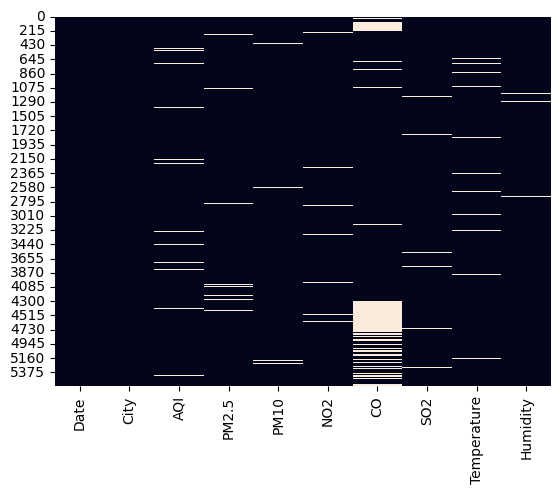

In [13]:
import seaborn as sns
import matplotlib.pylab as plt

sns.heatmap(df.isnull(),cbar=False)
plt.show()

In [15]:
numeric_cols=df.select_dtypes(['int64','float64']).columns

In [16]:
from scipy.stats import zscore

def zscore_outliers(column):
    z_scores = zscore(df[column])
    return np.sum(np.abs(z_scores) > 3)

for col in numeric_cols:
    print(f"{col}: {zscore_outliers(col)} outliers (Z-score)")

AQI: 0 outliers (Z-score)
PM2.5: 0 outliers (Z-score)
PM10: 0 outliers (Z-score)
NO2: 0 outliers (Z-score)
CO: 0 outliers (Z-score)
SO2: 0 outliers (Z-score)
Temperature: 0 outliers (Z-score)
Humidity: 0 outliers (Z-score)


In [17]:
def iqr_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return ((df[column] < lower) | (df[column] > upper)).sum()

for col in numeric_cols:
    print(f"{col}: {iqr_outliers(col)} outliers (IQR)")

AQI: 34 outliers (IQR)
PM2.5: 47 outliers (IQR)
PM10: 47 outliers (IQR)
NO2: 33 outliers (IQR)
CO: 30 outliers (IQR)
SO2: 40 outliers (IQR)
Temperature: 0 outliers (IQR)
Humidity: 0 outliers (IQR)


In [18]:
def modified_zscore_outliers(column):
    median = np.median(df[column])
    MAD = np.median(np.abs(df[column] - median))
    
    modified_z = 0.6745 * (df[column] - median) / MAD
    return np.sum(np.abs(modified_z) > 3.5)

for col in numeric_cols:
    print(f"{col}: {modified_zscore_outliers(col)} outliers (Modified Z-score)")

AQI: 0 outliers (Modified Z-score)
PM2.5: 0 outliers (Modified Z-score)
PM10: 0 outliers (Modified Z-score)
NO2: 0 outliers (Modified Z-score)
CO: 0 outliers (Modified Z-score)
SO2: 0 outliers (Modified Z-score)
Temperature: 0 outliers (Modified Z-score)
Humidity: 0 outliers (Modified Z-score)
